Copyright 2026 Kevin Zambello

This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.

This program is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU General Public License for more details.

You should have received a copy of the GNU General Public License along with this program. If not, see https://www.gnu.org/licenses/.

In [1]:
%load_ext autoreload
%autoreload 2

import importlib
import sys

sys.path.insert(1, '../..')

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model

from sklearn.model_selection import train_test_split

import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import scipy.special

import cpadenn
from cpadenn import Layers, Models, Utils

In [2]:
def n_thirring1d(mu, beta=1.0, L=8.0, m=2.0):

    mu = np.complex128(mu)

    I0 = scipy.special.iv(0, beta)
    I1 = scipy.special.iv(1, beta)
    mtilde = L*np.asinh(m)
    
    res = I1**L * np.sinh(L*mu)
    res = res / (I1**L * np.cosh(L*mu) + I0**L * np.cosh(mtilde))

    return res

In [3]:
def n_thirring1d_sing(beta=1.0, L=8.0, m=2.0):
    
    I0 = scipy.special.iv(0, beta)
    I1 = scipy.special.iv(1, beta)
    mtilde = L*np.asinh(m)

    res = (1.0/L) * np.acosh(   np.complex128(- I0**L / I1**L * np.cosh(mtilde))   )
    
    res_arr = res + np.array([1.0j*2.0*np.pi*n/L for n in range(-5,5)])
    res_arr = np.append(res_arr, -res_arr)

    return res_arr

Text(0.5, 0, '$Re[\\mu]$')

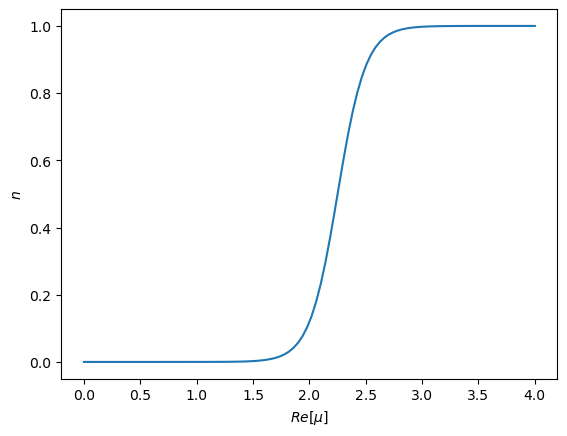

In [4]:
mymu = np.linspace(0., 4., 100)
plt.plot(mymu, n_thirring1d(mymu).real)
plt.ylabel('$n$')
plt.xlabel('$Re[\mu]$')

In [5]:
n_thirring1d_sing()

array([ 2.25019782-3.53429174j,  2.25019782-2.74889357j,
        2.25019782-1.96349541j,  2.25019782-1.17809725j,
        2.25019782-0.39269908j,  2.25019782+0.39269908j,
        2.25019782+1.17809725j,  2.25019782+1.96349541j,
        2.25019782+2.74889357j,  2.25019782+3.53429174j,
       -2.25019782+3.53429174j, -2.25019782+2.74889357j,
       -2.25019782+1.96349541j, -2.25019782+1.17809725j,
       -2.25019782+0.39269908j, -2.25019782-0.39269908j,
       -2.25019782-1.17809725j, -2.25019782-1.96349541j,
       -2.25019782-2.74889357j, -2.25019782-3.53429174j])

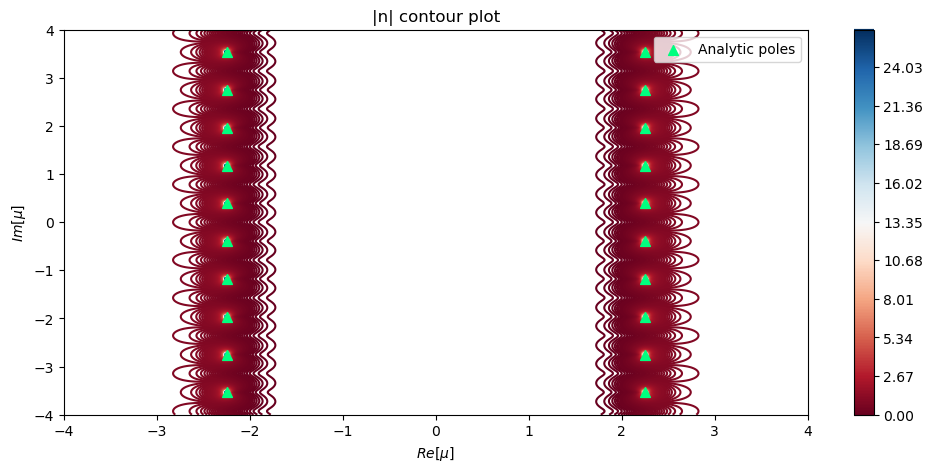

In [6]:
pts = 400
xg = np.linspace(-4, 4, pts)
yg = np.linspace(-4, 4, pts)
Xg, Yg = np.meshgrid(xg, yg)
Zg = Xg + 1.0j*Yg
out = n_thirring1d(Zg)

real_out = out.reshape(Xg.shape)
imag_out = out.imag.reshape(Yg.shape)
abs_out = np.abs(real_out + 1.0j * imag_out)

analytic_sings = n_thirring1d_sing()

plt.figure(figsize=(12, 5))
plt.contour(Xg, Yg, abs_out, levels=1000, cmap='RdBu')
#plt.contourf(Xg, Yg, abs_out, levels=1000, cmap='RdBu')
plt.colorbar()
plt.scatter(analytic_sings.real, analytic_sings.imag, color='springgreen', marker='^', s=50, zorder=2, label='Analytic poles')
plt.xlabel('$Re[\mu]$')
plt.ylabel('$Im[\mu]$')
plt.title('|n| contour plot')
#plt.title('|n|')
plt.legend()

Text(0.5, 1.0, 'Test data')

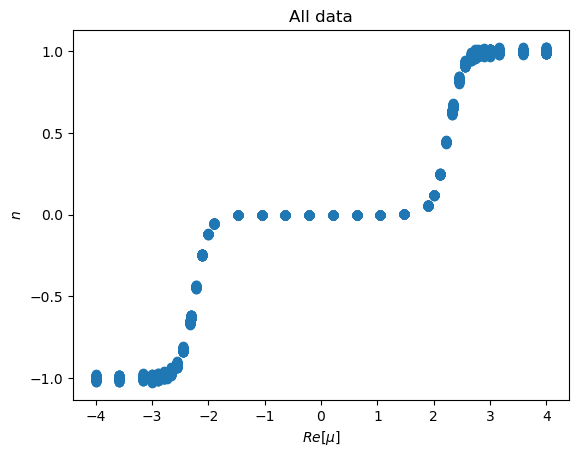

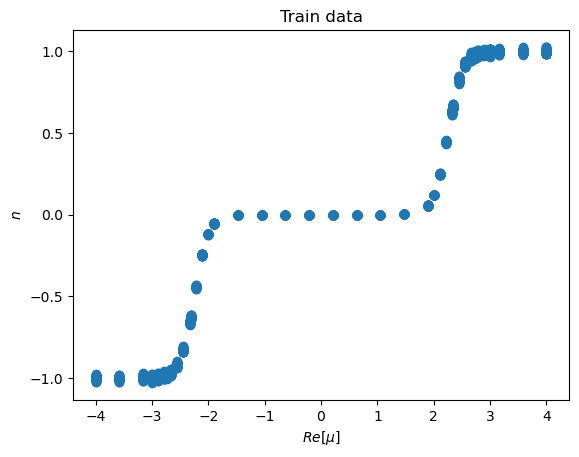

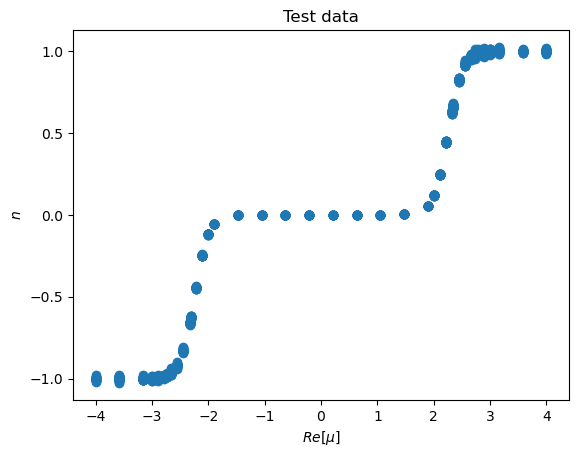

In [7]:
epsilon = 0.01

mu_ = np.linspace(-4.0,4.0,20)
mu_ = np.append(mu_, np.linspace(2.0,3.0,10))
mu_ = np.append(mu_, np.linspace(-3.0,-2.0,10))
mu_ = np.sort(mu_)

n_ = n_thirring1d(mu_)
dn_ = np.abs(n_) * epsilon

mu_sampled = mu_ 
n_sampled = n_ + dn_*np.random.randn(dn_.size)

for n in np.arange(100):
    mu_sampled = np.append(mu_sampled, mu_)
    n_sampled = np.append(n_sampled, n_ + dn_*np.random.randn(dn_.size))
    
X = np.transpose(np.stack([np.real(mu_sampled), np.imag(mu_sampled)]))
Y = np.transpose(np.stack([np.real(n_sampled), np.imag(n_sampled)]))

plt.figure()
plt.plot(X[:,0], Y[:,0], 'o', ls='')
plt.xlabel('$Re[\mu]$')
plt.ylabel('$n$')
plt.title('All data')

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, shuffle=True, random_state=42)

plt.figure()
plt.plot(X_train[:,0], Y_train[:,0], 'o', ls='')
plt.xlabel('$Re[\mu]$')
plt.ylabel('$n$')
plt.title('Train data')

plt.figure()
plt.plot(X_test[:,0], Y_test[:,0], 'o', ls='')
plt.xlabel('$Re[\mu]$')
plt.ylabel('$n$')
plt.title('Test data')

In [8]:
modelNN_run1 = cpadenn.Models.CustomModel(units=[4,4,4,1], n=[4,4,4,-1], m=[4,4,4,-1], safe=[False,False,False,-1])
optadam = tf.keras.optimizers.Adam(learning_rate=1.0e-3)

modelNN_run1.compile(optimizer = optadam, loss='mean_squared_error')

EarlyStop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
ReduceLR = ReduceLROnPlateau(monitor='loss',factor=0.5,patience=5,min_lr=1e-6)

histNN_run1 = modelNN_run1.fit(X_train, Y_train, epochs=500, batch_size=128, validation_data=(X_test, Y_test), callbacks=[ReduceLR, EarlyStop])

print(modelNN_run1.summary())

Epoch 1/500


2026-04-20 14:14:01.261853: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 94ms/step - loss: 0.2450 - val_loss: 0.1526 - learning_rate: 0.0010
Epoch 2/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0997 - val_loss: 0.0332 - learning_rate: 0.0010
Epoch 3/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0339 - val_loss: 0.0291 - learning_rate: 0.0010
Epoch 4/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0271 - val_loss: 0.0253 - learning_rate: 0.0010
Epoch 5/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0232 - val_loss: 0.0176 - learning_rate: 0.0010
Epoch 6/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0139 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 7/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0022 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 8/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0015 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 9/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0013 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 10/500
23/23 ━━

Epoch 55/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.9483e-05 - val_loss: 7.6990e-05 - learning_rate: 3.1250e-05
Epoch 56/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.9413e-05 - val_loss: 7.6931e-05 - learning_rate: 3.1250e-05
Epoch 57/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.7754e-05 - val_loss: 7.6618e-05 - learning_rate: 3.1250e-05
Epoch 58/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.7203e-05 - val_loss: 7.6349e-05 - learning_rate: 3.1250e-05
Epoch 59/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.9899e-05 - val_loss: 7.6321e-05 - learning_rate: 1.5625e-05
Epoch 60/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.0670e-05 - val_loss: 7.6245e-05 - learning_rate: 1.5625e-05
Epoch 61/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.9448e-05 - val_loss: 7.6149e-05 - learning_rate: 1.5625e-05
Epoch 62/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.7429e-05 - val_loss: 7.6053e-05 - learning_rate: 1.5625e-05
Epoch 63/500
23/

Epoch 159/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.7218e-05 - val_loss: 7.4476e-05 - learning_rate: 1.0000e-06
Epoch 160/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.6972e-05 - val_loss: 7.4540e-05 - learning_rate: 1.0000e-06
Epoch 161/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.7127e-05 - val_loss: 7.4531e-05 - learning_rate: 1.0000e-06
Epoch 162/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.6339e-05 - val_loss: 7.4506e-05 - learning_rate: 1.0000e-06
Epoch 163/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.6916e-05 - val_loss: 7.4458e-05 - learning_rate: 1.0000e-06
Epoch 164/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.9377e-05 - val_loss: 7.4426e-05 - learning_rate: 1.0000e-06
Epoch 165/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.8100e-05 - val_loss: 7.4424e-05 - learning_rate: 1.0000e-06
Epoch 166/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.6473e-05 - val_loss: 7.4396e-05 - learning_rate: 1.0000e-06
Epoch 16

...

 Total params: 482 (1.89 KB)

 Trainable params: 160 (640.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 322 (1.26 KB)

None


In [9]:
modelNN_run2 = cpadenn.Models.CustomModel(units=[4,4,4,1], n=[3,3,3,-1], m=[3,3,3,-1], safe=[False,False,False,-1])
optadam = tf.keras.optimizers.Adam(learning_rate=1.0e-3)

modelNN_run2.compile(optimizer = optadam, loss='mean_squared_error')

EarlyStop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
ReduceLR = ReduceLROnPlateau(monitor='loss',factor=0.5,patience=5,min_lr=1e-6)

histNN_run2 = modelNN_run2.fit(X_train, Y_train, epochs=500, batch_size=128, validation_data=(X_test, Y_test), callbacks=[ReduceLR, EarlyStop])

print(modelNN_run2.summary())

Epoch 1/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 82ms/step - loss: 0.2488 - val_loss: 0.1553 - learning_rate: 0.0010
Epoch 2/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1055 - val_loss: 0.0326 - learning_rate: 0.0010
Epoch 3/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0336 - val_loss: 0.0318 - learning_rate: 0.0010
Epoch 4/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0289 - val_loss: 0.0279 - learning_rate: 0.0010
Epoch 5/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0263 - val_loss: 0.0254 - learning_rate: 0.0010
Epoch 6/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0242 - val_loss: 0.0214 - learning_rate: 0.0010
Epoch 7/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0185 - val_loss: 0.0079 - learning_rate: 0.0010
Epoch 8/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0052 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 9/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0022 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 10/

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.0441e-05 - val_loss: 7.7327e-05 - learning_rate: 1.0000e-06
Epoch 107/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.0254e-05 - val_loss: 7.7379e-05 - learning_rate: 1.0000e-06
Epoch 108/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.0974e-05 - val_loss: 7.7308e-05 - learning_rate: 1.0000e-06
Epoch 109/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 8.0336e-05 - val_loss: 7.7303e-05 - learning_rate: 1.0000e-06
Epoch 110/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.6871e-05 - val_loss: 7.7296e-05 - learning_rate: 1.0000e-06
Epoch 111/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 8.0480e-05 - val_loss: 7.7221e-05 - learning_rate: 1.0000e-06
Epoch 112/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 8.1095e-05 - val_loss: 7.7228e-05 - learning_rate: 1.0000e-06
Epoch 113/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.9103e-05 - val_loss: 7.7221e-05 - learning_rate: 1.0000e-06
Epoch 114/500
23/23 ━━

Epoch 158/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.8804e-05 - val_loss: 7.6475e-05 - learning_rate: 1.0000e-06
Epoch 159/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.8951e-05 - val_loss: 7.6422e-05 - learning_rate: 1.0000e-06
Epoch 160/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.8925e-05 - val_loss: 7.6392e-05 - learning_rate: 1.0000e-06
Epoch 161/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.7610e-05 - val_loss: 7.6355e-05 - learning_rate: 1.0000e-06
Epoch 162/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.8613e-05 - val_loss: 7.6370e-05 - learning_rate: 1.0000e-06
Epoch 163/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 7.8628e-05 - val_loss: 7.6426e-05 - learning_rate: 1.0000e-06
Epoch 164/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.9042e-05 - val_loss: 7.6388e-05 - learning_rate: 1.0000e-06
Epoch 165/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 7.8457e-05 - val_loss: 7.6355e-05 - learning_rate: 1.0000e-06
Epoch 16

Epoch 210/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.6680e-05 - val_loss: 7.5185e-05 - learning_rate: 1.0000e-06
Epoch 211/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.4018e-05 - val_loss: 7.5273e-05 - learning_rate: 1.0000e-06
Epoch 212/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.6099e-05 - val_loss: 7.5173e-05 - learning_rate: 1.0000e-06
Epoch 213/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 8.0846e-05 - val_loss: 7.5114e-05 - learning_rate: 1.0000e-06
Epoch 214/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.6107e-05 - val_loss: 7.4973e-05 - learning_rate: 1.0000e-06
Epoch 215/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.6458e-05 - val_loss: 7.4945e-05 - learning_rate: 1.0000e-06
Epoch 216/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.0475e-05 - val_loss: 7.4948e-05 - learning_rate: 1.0000e-06
Epoch 217/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 7.6640e-05 - val_loss: 7.4850e-05 - learning_rate: 1.0000e-06
Epoch 21

Epoch 262/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.3572e-05 - val_loss: 7.3232e-05 - learning_rate: 1.0000e-06
Epoch 263/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 7.6220e-05 - val_loss: 7.3147e-05 - learning_rate: 1.0000e-06
Epoch 264/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 7.4499e-05 - val_loss: 7.3169e-05 - learning_rate: 1.0000e-06
Epoch 265/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.4597e-05 - val_loss: 7.3172e-05 - learning_rate: 1.0000e-06
Epoch 266/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.6242e-05 - val_loss: 7.3129e-05 - learning_rate: 1.0000e-06
Epoch 267/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.6446e-05 - val_loss: 7.3049e-05 - learning_rate: 1.0000e-06
Epoch 268/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.3838e-05 - val_loss: 7.3014e-05 - learning_rate: 1.0000e-06
Epoch 269/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.6255e-05 - val_loss: 7.2983e-05 - learning_rate: 1.0000e-06
Epoch 27

...

 Total params: 446 (1.75 KB)

 Trainable params: 148 (592.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 298 (1.17 KB)

None


In [10]:
modelNN_run3 = cpadenn.Models.CustomModel(units=[8,8,1], n=[4,4,-1], m=[4,4,-1], safe=[False,False,-1])
optadam = tf.keras.optimizers.Adam(learning_rate=1.0e-3)

modelNN_run3.compile(optimizer = optadam, loss='mean_squared_error')

EarlyStop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
ReduceLR = ReduceLROnPlateau(monitor='loss',factor=0.5,patience=5,min_lr=1e-6)

histNN_run3 = modelNN_run3.fit(X_train, Y_train, epochs=500, batch_size=128, validation_data=(X_test, Y_test), callbacks=[ReduceLR, EarlyStop])

print(modelNN_run3.summary())

Epoch 1/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - loss: 0.2356 - val_loss: 0.0399 - learning_rate: 0.0010
Epoch 2/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0346 - val_loss: 0.0314 - learning_rate: 0.0010
Epoch 3/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0312 - val_loss: 0.0311 - learning_rate: 0.0010
Epoch 4/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0300 - val_loss: 0.0307 - learning_rate: 0.0010
Epoch 5/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0297 - val_loss: 0.0300 - learning_rate: 0.0010
Epoch 6/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0285 - val_loss: 0.0298 - learning_rate: 0.0010
Epoch 7/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0291 - val_loss: 0.0294 - learning_rate: 0.0010
Epoch 8/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0289 - val_loss: 0.0295 - learning_rate: 0.0010
Epoch 9/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0285 - val_loss: 0.0288 - learning_rate: 0.0010
Epoch 10/

Epoch 57/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.0234e-05 - val_loss: 8.7720e-05 - learning_rate: 5.0000e-04
Epoch 58/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 8.6311e-05 - val_loss: 8.7107e-05 - learning_rate: 5.0000e-04
Epoch 59/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.0286e-05 - val_loss: 9.0381e-05 - learning_rate: 5.0000e-04
Epoch 60/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.5650e-05 - val_loss: 8.1108e-05 - learning_rate: 5.0000e-04
Epoch 61/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.5781e-05 - val_loss: 7.9230e-05 - learning_rate: 2.5000e-04
Epoch 62/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.8322e-05 - val_loss: 7.7343e-05 - learning_rate: 2.5000e-04
Epoch 63/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 7.7182e-05 - val_loss: 7.6122e-05 - learning_rate: 2.5000e-04
Epoch 64/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.7023e-05 - val_loss: 7.5596e-05 - learning_rate: 2.5000e-04
Epoch 65/500
23/

Epoch 161/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.4781e-05 - val_loss: 6.7849e-05 - learning_rate: 1.0000e-06
Epoch 162/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.2005e-05 - val_loss: 6.7842e-05 - learning_rate: 1.0000e-06
Epoch 163/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.4728e-05 - val_loss: 6.7796e-05 - learning_rate: 1.0000e-06
Epoch 164/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.7031e-05 - val_loss: 6.7748e-05 - learning_rate: 1.0000e-06
Epoch 165/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.5491e-05 - val_loss: 6.7747e-05 - learning_rate: 1.0000e-06
Epoch 166/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.4396e-05 - val_loss: 6.7768e-05 - learning_rate: 1.0000e-06
Epoch 167/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.4376e-05 - val_loss: 6.7768e-05 - learning_rate: 1.0000e-06
Epoch 168/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.7132e-05 - val_loss: 6.7761e-05 - learning_rate: 1.0000e-06
Epoch 16

Epoch 213/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.3550e-05 - val_loss: 6.7121e-05 - learning_rate: 1.0000e-06
Epoch 214/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.7069e-05 - val_loss: 6.7087e-05 - learning_rate: 1.0000e-06
Epoch 215/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6.3805e-05 - val_loss: 6.7134e-05 - learning_rate: 1.0000e-06
Epoch 216/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 6.3396e-05 - val_loss: 6.7053e-05 - learning_rate: 1.0000e-06
Epoch 217/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 6.3350e-05 - val_loss: 6.7015e-05 - learning_rate: 1.0000e-06
Epoch 218/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 6.5234e-05 - val_loss: 6.7043e-05 - learning_rate: 1.0000e-06
Epoch 219/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.5169e-05 - val_loss: 6.7063e-05 - learning_rate: 1.0000e-06
Epoch 220/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.4696e-05 - val_loss: 6.7144e-05 - learning_rate: 1.0000e-06
Epoch 22

Epoch 265/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6.4126e-05 - val_loss: 6.5993e-05 - learning_rate: 1.0000e-06
Epoch 266/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.6870e-05 - val_loss: 6.5985e-05 - learning_rate: 1.0000e-06
Epoch 267/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.2314e-05 - val_loss: 6.5893e-05 - learning_rate: 1.0000e-06
Epoch 268/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6.6016e-05 - val_loss: 6.5786e-05 - learning_rate: 1.0000e-06
Epoch 269/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.3074e-05 - val_loss: 6.5822e-05 - learning_rate: 1.0000e-06
Epoch 270/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.2872e-05 - val_loss: 6.5792e-05 - learning_rate: 1.0000e-06
Epoch 271/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.2926e-05 - val_loss: 6.5790e-05 - learning_rate: 1.0000e-06
Epoch 272/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.4800e-05 - val_loss: 6.5813e-05 - learning_rate: 1.0000e-06
Epoch 27

...

 Total params: 692 (2.71 KB)

 Trainable params: 230 (920.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 462 (1.81 KB)

None


In [11]:
modelNN_run4 = cpadenn.Models.CustomModel(units=[8,8,1], n=[3,3,-1], m=[3,3,-1], safe=[False,False,-1])
optadam = tf.keras.optimizers.Adam(learning_rate=1.0e-3)

modelNN_run4.compile(optimizer = optadam, loss='mean_squared_error')

EarlyStop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
ReduceLR = ReduceLROnPlateau(monitor='loss',factor=0.5,patience=5,min_lr=1e-6)

histNN_run4 = modelNN_run4.fit(X_train, Y_train, epochs=500, batch_size=128, validation_data=(X_test, Y_test), callbacks=[ReduceLR, EarlyStop])

print(modelNN_run4.summary())

Epoch 1/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - loss: 0.2504 - val_loss: 0.0541 - learning_rate: 0.0010
Epoch 2/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0406 - val_loss: 0.0304 - learning_rate: 0.0010
Epoch 3/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0307 - val_loss: 0.0311 - learning_rate: 0.0010
Epoch 4/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0292 - val_loss: 0.0300 - learning_rate: 0.0010
Epoch 5/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0302 - val_loss: 0.0301 - learning_rate: 0.0010
Epoch 6/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0293 - val_loss: 0.0297 - learning_rate: 0.0010
Epoch 7/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0290 - val_loss: 0.0294 - learning_rate: 0.0010
Epoch 8/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0290 - val_loss: 0.0292 - learning_rate: 0.0010
Epoch 9/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0288 - val_loss: 0.0291 - learning_rate: 0.0010
Epoch 10/

Model: "custom_model_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ c_merge_re_im_3 (CMergeReIm)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_dense_11 (CDense)             │ ?                      │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_pade_af_8 (CPadeAF)           │ ?                      │            14 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_dense_12 (CDense)             │ ?                      │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_pade_af_9 (CPadeAF)           │ ?                      │            14 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_dense_13 (CDense)             │ ?                      │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_split_re_im_3 (CSplitReIm)    │ ?                      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668 (2.61 KB)

 Trainable params: 222 (888.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 446 (1.75 KB)

None


In [12]:
modelNN_run5 = cpadenn.Models.CustomModel(units=[9,9,1], n=[4,4,-1], m=[4,4,-1], safe=[False,False,-1])
optadam = tf.keras.optimizers.Adam(learning_rate=1.0e-3)

modelNN_run5.compile(optimizer = optadam, loss='mean_squared_error')

EarlyStop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
ReduceLR = ReduceLROnPlateau(monitor='loss',factor=0.5,patience=5,min_lr=1e-6)

histNN_run5 = modelNN_run5.fit(X_train, Y_train, epochs=500, batch_size=128, validation_data=(X_test, Y_test), callbacks=[ReduceLR, EarlyStop])

print(modelNN_run5.summary())

Epoch 1/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - loss: 0.2408 - val_loss: 0.0318 - learning_rate: 0.0010
Epoch 2/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0344 - val_loss: 0.0316 - learning_rate: 0.0010
Epoch 3/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0297 - val_loss: 0.0307 - learning_rate: 0.0010
Epoch 4/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0292 - val_loss: 0.0308 - learning_rate: 0.0010
Epoch 5/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0295 - val_loss: 0.0302 - learning_rate: 0.0010
Epoch 6/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0294 - val_loss: 0.0298 - learning_rate: 0.0010
Epoch 7/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0279 - val_loss: 0.0295 - learning_rate: 0.0010
Epoch 8/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0288 - val_loss: 0.0298 - learning_rate: 0.0010
Epoch 9/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0292 - val_loss: 0.0293 - learning_rate: 0.0010
Epoch 10/

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5.7469e-05 - val_loss: 5.8795e-05 - learning_rate: 1.0000e-06
Epoch 110/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.8850e-05 - val_loss: 5.8813e-05 - learning_rate: 1.0000e-06
Epoch 111/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5.9162e-05 - val_loss: 5.8830e-05 - learning_rate: 1.0000e-06
Epoch 112/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.7767e-05 - val_loss: 5.8828e-05 - learning_rate: 1.0000e-06
Epoch 113/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.7490e-05 - val_loss: 5.8838e-05 - learning_rate: 1.0000e-06
Epoch 114/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5.9257e-05 - val_loss: 5.8841e-05 - learning_rate: 1.0000e-06
Epoch 115/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6.1662e-05 - val_loss: 5.8821e-05 - learning_rate: 1.0000e-06
Epoch 116/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5.5946e-05 - val_loss: 5.8782e-05 - learning_rate: 1.0000e-06
Epoch 117/500
23/23 ━━

Epoch 161/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.8150e-05 - val_loss: 5.8163e-05 - learning_rate: 1.0000e-06
Epoch 162/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5.9181e-05 - val_loss: 5.8153e-05 - learning_rate: 1.0000e-06
Epoch 163/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.8295e-05 - val_loss: 5.8171e-05 - learning_rate: 1.0000e-06
Epoch 164/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.8201e-05 - val_loss: 5.8169e-05 - learning_rate: 1.0000e-06
Epoch 165/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.5811e-05 - val_loss: 5.8140e-05 - learning_rate: 1.0000e-06
Epoch 166/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5.6942e-05 - val_loss: 5.8078e-05 - learning_rate: 1.0000e-06
Epoch 167/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.7177e-05 - val_loss: 5.8070e-05 - learning_rate: 1.0000e-06
Epoch 168/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5.5685e-05 - val_loss: 5.8055e-05 - learning_rate: 1.0000e-06
Epoch 16

Epoch 213/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.5936e-05 - val_loss: 5.7107e-05 - learning_rate: 1.0000e-06
Epoch 214/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.7643e-05 - val_loss: 5.7076e-05 - learning_rate: 1.0000e-06
Epoch 215/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.8983e-05 - val_loss: 5.7066e-05 - learning_rate: 1.0000e-06
Epoch 216/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 5.6973e-05 - val_loss: 5.7067e-05 - learning_rate: 1.0000e-06
Epoch 217/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.8075e-05 - val_loss: 5.7000e-05 - learning_rate: 1.0000e-06
Epoch 218/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 5.5977e-05 - val_loss: 5.6951e-05 - learning_rate: 1.0000e-06
Epoch 219/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5.7535e-05 - val_loss: 5.6921e-05 - learning_rate: 1.0000e-06
Epoch 220/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.7681e-05 - val_loss: 5.6889e-05 - learning_rate: 1.0000e-06
Epoch 22

Epoch 265/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 5.5530e-05 - val_loss: 5.5420e-05 - learning_rate: 1.0000e-06
Epoch 266/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5.7784e-05 - val_loss: 5.5328e-05 - learning_rate: 1.0000e-06
Epoch 267/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.8503e-05 - val_loss: 5.5375e-05 - learning_rate: 1.0000e-06
Epoch 268/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.6655e-05 - val_loss: 5.5375e-05 - learning_rate: 1.0000e-06
Epoch 269/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 5.4606e-05 - val_loss: 5.5335e-05 - learning_rate: 1.0000e-06
Epoch 270/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5.5004e-05 - val_loss: 5.5164e-05 - learning_rate: 1.0000e-06
Epoch 271/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.6009e-05 - val_loss: 5.5194e-05 - learning_rate: 1.0000e-06
Epoch 272/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5.3719e-05 - val_loss: 5.5157e-05 - learning_rate: 1.0000e-06
Epoch 27

...

 Total params: 818 (3.20 KB)

 Trainable params: 272 (1.06 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 546 (2.14 KB)

None


In [13]:
modelNN_run6 = cpadenn.Models.CustomModel(units=[9,9,1], n=[3,3,-1], m=[3,3,-1], safe=[False,False,-1])
optadam = tf.keras.optimizers.Adam(learning_rate=1.0e-3)

modelNN_run6.compile(optimizer = optadam, loss='mean_squared_error')

EarlyStop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
ReduceLR = ReduceLROnPlateau(monitor='loss',factor=0.5,patience=5,min_lr=1e-6)

histNN_run6 = modelNN_run6.fit(X_train, Y_train, epochs=500, batch_size=128, validation_data=(X_test, Y_test), callbacks=[ReduceLR, EarlyStop])

print(modelNN_run6.summary())

Epoch 1/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - loss: 0.2516 - val_loss: 0.0325 - learning_rate: 0.0010
Epoch 2/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0328 - val_loss: 0.0308 - learning_rate: 0.0010
Epoch 3/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0303 - val_loss: 0.0308 - learning_rate: 0.0010
Epoch 4/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0292 - val_loss: 0.0300 - learning_rate: 0.0010
Epoch 5/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0288 - val_loss: 0.0298 - learning_rate: 0.0010
Epoch 6/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0288 - val_loss: 0.0299 - learning_rate: 0.0010
Epoch 7/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0287 - val_loss: 0.0295 - learning_rate: 0.0010
Epoch 8/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0271 - val_loss: 0.0293 - learning_rate: 0.0010
Epoch 9/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0289 - val_loss: 0.0293 - learning_rate: 0.0010
Epoch 10

Epoch 110/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.1056e-05 - val_loss: 3.7744e-05 - learning_rate: 7.8125e-06
Epoch 111/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.9984e-05 - val_loss: 3.7726e-05 - learning_rate: 7.8125e-06
Epoch 112/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.0766e-05 - val_loss: 3.7729e-05 - learning_rate: 7.8125e-06
Epoch 113/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.0153e-05 - val_loss: 3.7764e-05 - learning_rate: 7.8125e-06
Epoch 114/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.0123e-05 - val_loss: 3.7770e-05 - learning_rate: 3.9063e-06
Epoch 115/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.9823e-05 - val_loss: 3.7762e-05 - learning_rate: 3.9063e-06
Epoch 116/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.0400e-05 - val_loss: 3.7770e-05 - learning_rate: 3.9063e-06


Model: "custom_model_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ c_merge_re_im_5 (CMergeReIm)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_dense_17 (CDense)             │ ?                      │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_pade_af_12 (CPadeAF)          │ ?                      │            14 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_dense_18 (CDense)             │ ?                      │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_pade_af_13 (CPadeAF)          │ ?                      │            14 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_dense_19 (CDense)             │ ?                      │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_split_re_im_5 (CSplitReIm)    │ ?                      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 794 (3.11 KB)

 Trainable params: 264 (1.03 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 530 (2.07 KB)

None


In [14]:
models = [modelNN_run1, modelNN_run2, modelNN_run3, modelNN_run4, modelNN_run5, modelNN_run6]
names = ['ML model (run1)', 'ML model (run2)', 'ML model (run3)', 'ML model (run4)','ML model (run5)','ML model (run6)']
colors = ['green', 'red', 'blue', 'magenta', 'limegreen', 'cyan']

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step 


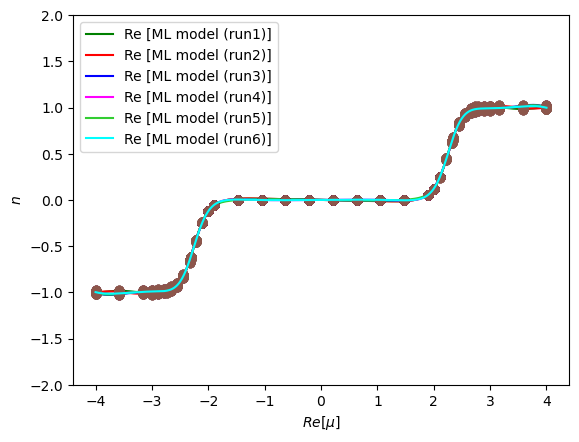

In [15]:
mu_pred = np.linspace(-4,4,1000)

plt.figure()
for n in np.arange(len(models)):
    X_pred = np.transpose(np.stack([np.real(mu_pred), np.imag(mu_pred)]))
    Y_pred = models[n].predict(X_pred)

    plt.plot(X[:,0], Y[:,0], 'o', ls='')
    plt.plot(X_pred[:,0], Y_pred[:,0], color=colors[n], label='Re ['+names[n]+']')
    plt.legend()
    plt.xlabel('$Re[\mu]$')
    plt.ylabel('$n$')
    plt.ylim(-2,2)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


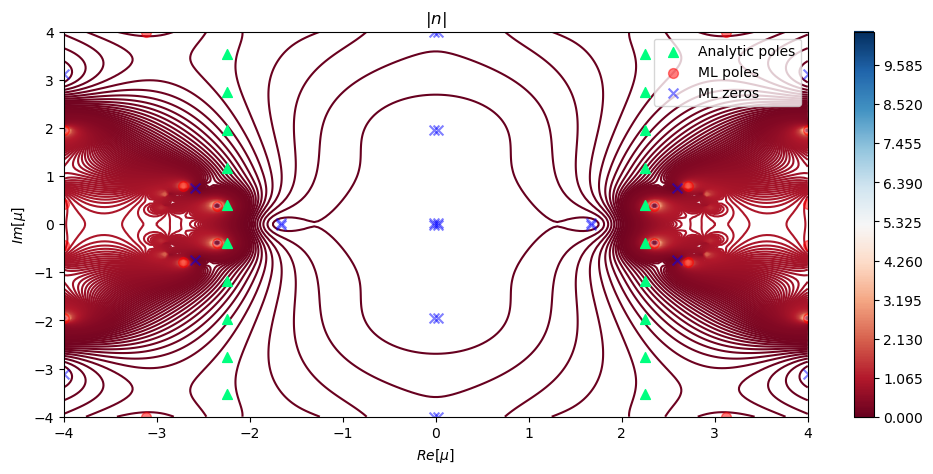

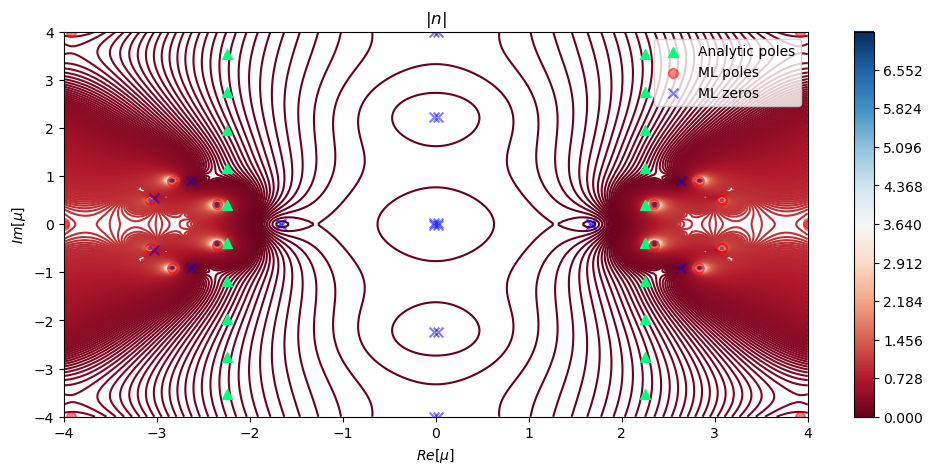

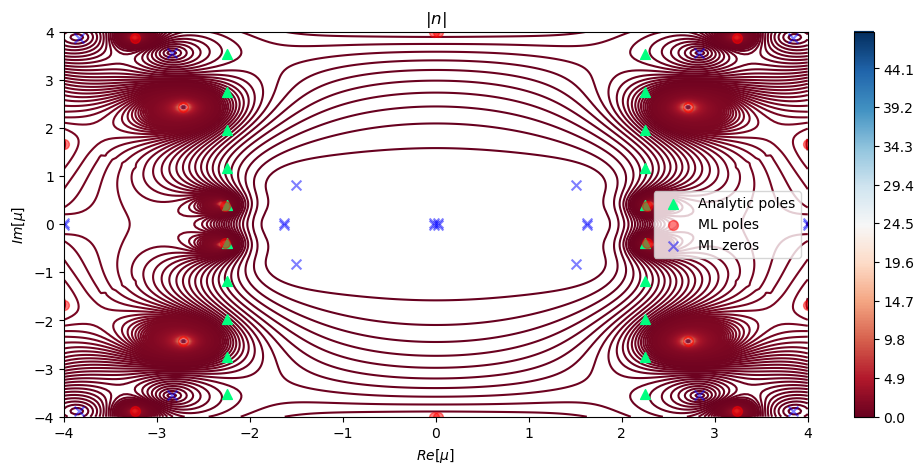

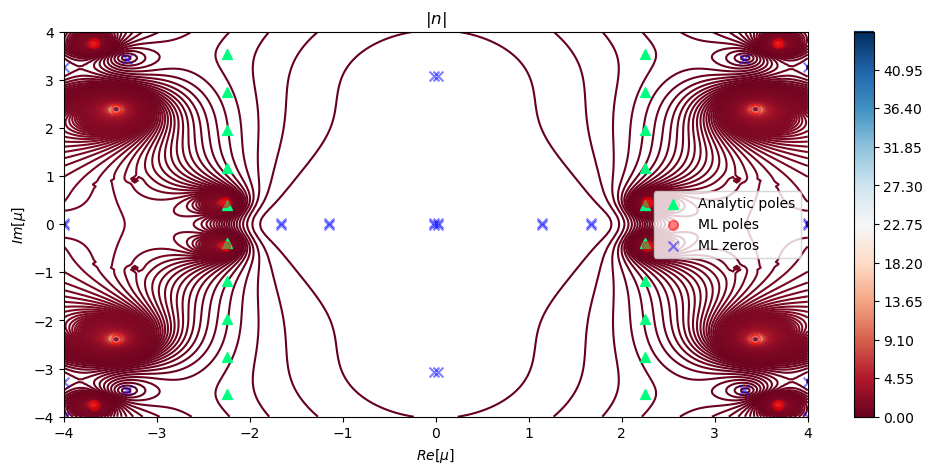

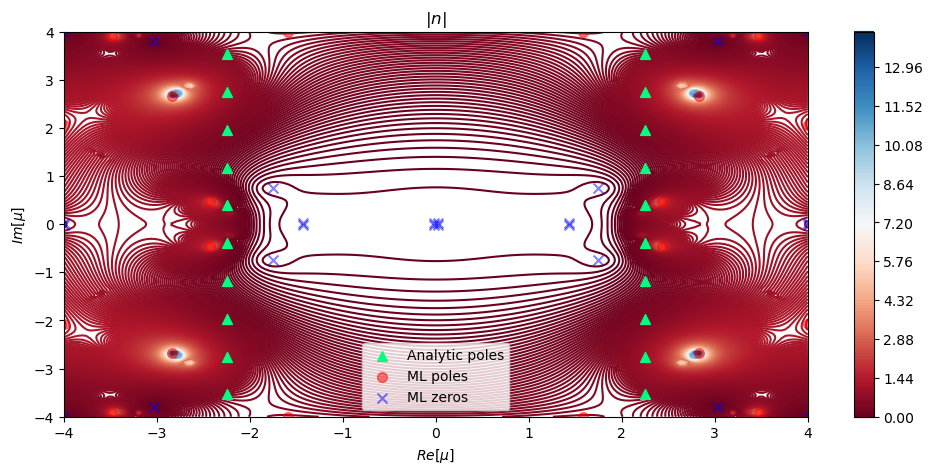

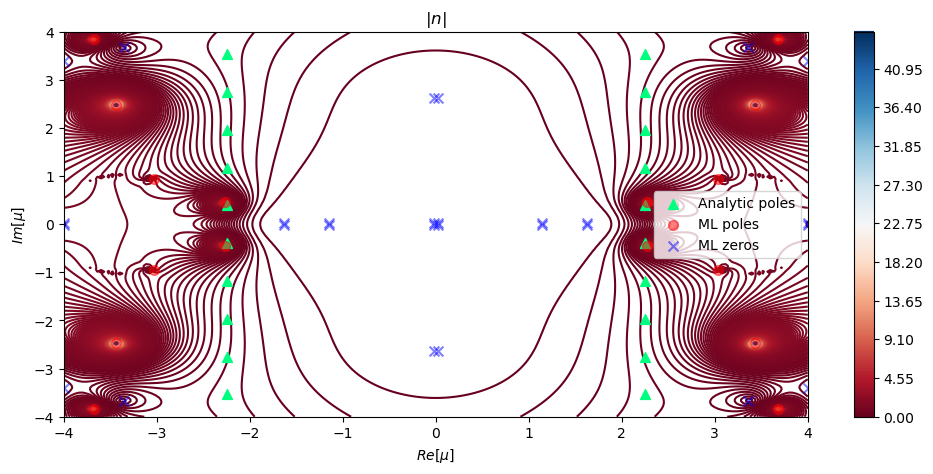

In [16]:
for n in np.arange(len(models)):
    pts = 200
    xg = np.linspace(-4, 4, pts)
    yg = np.linspace(-4, 4, pts)
    Xg, Yg = np.meshgrid(xg, yg)
    Zg = np.stack([Xg.ravel(), Yg.ravel()], axis=-1).astype(np.float32)
    out = models[n].predict(Zg)

    real_out = out[:, 0].reshape(Xg.shape)
    imag_out = out[:, 1].reshape(Yg.shape)
    abs_out = np.abs(real_out + 1.0j * imag_out)

    poles = cpadenn.Utils.FindLocMax(Xg, Yg, abs_out)
    zeros = cpadenn.Utils.FindLocMax(Xg, Yg, 1.0/abs_out)

    analytic_sings = n_thirring1d_sing()

    plt.figure(figsize=(12, 5))
    plt.contour(Xg, Yg, abs_out, levels=1000, cmap='RdBu')
    #plt.contourf(Xg, Yg, abs_out, levels=1000, cmap='RdBu')
    plt.colorbar()
    plt.scatter(analytic_sings.real, analytic_sings.imag, color='springgreen', marker='^', s=50, zorder=2, label='Analytic poles')
    plt.scatter(poles[:,0], poles[:,1], color='red', marker='o', s=50, zorder=2, label='ML poles', alpha=0.5)
    plt.scatter(zeros[:,0], zeros[:,1], color='blue', marker='x', s=50, zorder=2, label='ML zeros', alpha=0.5)
    plt.xlabel('$Re[\mu]$')
    plt.ylabel('$Im[\mu]$')
    #plt.title('$|n|$ contour plot')
    plt.title('$|n|$')
    plt.legend()